# Classificação de Gêneros Musicais — Top 5 Gêneros

Usa o dataset já pré-processado (`df_modelagem`) com as colunas:
- `lyric_stemmed` → entrada para TF-IDF (limpeza + stopwords removidas + stemming)
- `tokens_stemmed` → entrada para Word2Vec (lista de tokens com stemming)
- `genre_list_final` → lista de gêneros já consolidados

## 1. Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score

print('Imports OK!')

Imports OK!


## 2. Carregamento do Dataset

In [3]:
# Ajuste o caminho se necessário
caminho = '/content/drive/MyDrive/Colab Notebooks/df_pre_divisao.csv'
df = pd.read_csv(caminho)

# As colunas de lista são salvas como string no CSV — convertemos de volta para lista
def parse_list_col(val):
    if isinstance(val, list):
        return val
    try:
        return ast.literal_eval(val)
    except:
        return []

df['genre_list_final'] = df['genre_list_final'].apply(parse_list_col)
df['tokens_stemmed']   = df['tokens_stemmed'].apply(parse_list_col)
df['tokens_final']     = df['tokens_final'].apply(parse_list_col)

# Garante que lyric_stemmed é string
df['lyric_stemmed'] = df['lyric_stemmed'].astype(str)

# Remove linhas sem gênero ou sem texto
df = df[df['genre_list_final'].map(len) > 0].copy()
df = df[df['lyric_stemmed'].str.strip() != ''].copy()
df = df.reset_index(drop=True)

print(f'Dataset carregado: {df.shape}')
df.head()

Dataset carregado: (43626, 11)


,index,Artist,SName,Lyric,Genres_Updated,lyric_limpo,tokens_final,genre_list,genre_list_final,lyric_stemmed,tokens_stemmed
0,0,Padre Fábio de Melo,Milagre de Amor,Quando ergo meus olhos pro céu e minha voz se ...,gospel,quando ergo meus olhos pro céu e minha voz se ...,"[ergo, olhos, pro, céu, voz, faz, canção, mila...",['gospel'],[gospel],qu erg meu olh pro céu e minh voz se faz cançã...,"[erg, olh, pro, céu, voz, faz, cançã, milagr, ..."
1,1,Falamansa,Caminhos do Coração,Há muito tempo que eu saí de casa Há muito tem...,forro; xote,há muito tempo que eu saí de casa há muito tem...,"[tempo, saí, casa, tempo, caí, estrada, tempo,...","['forro', 'xote']",[forro],há muit temp que eu saí de cas há muit temp qu...,"[temp, saí, cas, temp, caí, estr, temp, vid, a..."
2,2,Thiaguinho,Se Der Rolo,"Ei, confia cê sabe onde isso vai dar Cê quer s...",pagode; samba,ei confia cê sabe onde isso vai dar cê quer se...,"[ei, confia, cê, sabe, onde, vai, dar, cê, que...","['pagode', 'samba']",[samba],ei conf cê sab ond iss vai dar cê qu ser feliz...,"[ei, conf, cê, sab, ond, vai, dar, cê, qu, fel..."
3,3,Pollo,Fim de Semana na Quebrada (Part. Mc Pedrinho),Fim de semana na quebrada Fluxo a milhão Se De...,rap; hip hop,fim de semana na quebrada fluxo a milhão se de...,"[fim, semana, quebrada, fluxo, milhão, deus, q...","['rap', 'hip hop']",[hip hop],fim de seman na quebr flux a milhã se deu quis...,"[fim, seman, quebr, flux, milhã, deu, quis, pe..."
4,4,Milton Nascimento,Gran Circo,Vem chegando a lona suja o grande circo humano...,mpb,vem chegando a lona suja o grande circo humano...,"[vem, chegando, lona, suja, grande, circo, hum...",['mpb'],[mpb],vem cheg a lon suj o grand circ human com a fo...,"[vem, cheg, lon, suj, grand, circ, human, fom,..."


## 3. Treino Inicial — Descobre os Top 5 Gêneros

Treina uma Regressão Logística rápida com **todos** os gêneros disponíveis
e seleciona os 5 com melhor F1-score.

In [4]:
mlb_all = MultiLabelBinarizer()
y_all   = mlb_all.fit_transform(df['genre_list_final'])

print(f'Total de classes: {len(mlb_all.classes_)}')
print(f'Classes: {mlb_all.classes_}')

# Distribuição geral
contagem_all = df['genre_list_final'].explode().value_counts()
print('\nDistribuição:')
print(contagem_all)

Total de classes: 11
Classes: ['axe' 'forro' 'funk' 'gospel' 'hip hop' 'mpb' 'pop' 'reggae' 'rock'
 'samba' 'sertanejo']

Distribuição:
genre_list_final
mpb          15072
sertanejo     8524
pop           7639
samba         7630
gospel        7468
rock          6140
forro         3130
hip hop       2189
axe           2088
reggae        1348
funk          1245
Name: count, dtype: int64


In [5]:
X_all = df['lyric_stemmed']

X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

tfidf_all   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
Xv_tr_all   = tfidf_all.fit_transform(X_tr_all)
Xv_te_all   = tfidf_all.transform(X_te_all)

clf_probe = OneVsRestClassifier(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)
clf_probe.fit(Xv_tr_all, y_tr_all)
y_pred_probe = clf_probe.predict(Xv_te_all)

report_all = classification_report(
    y_te_all, y_pred_probe,
    target_names=mlb_all.classes_,
    output_dict=True
)
print(classification_report(y_te_all, y_pred_probe, target_names=mlb_all.classes_))

              precision    recall  f1-score   support

         axe       0.18      0.64      0.28       412
       forro       0.25      0.65      0.36       675
        funk       0.13      0.55      0.21       239
      gospel       0.85      0.90      0.88      1451
     hip hop       0.43      0.75      0.55       486
         mpb       0.62      0.76      0.69      3066
         pop       0.27      0.55      0.36      1521
      reggae       0.13      0.48      0.21       266
        rock       0.30      0.64      0.41      1233
       samba       0.36      0.69      0.47      1509
   sertanejo       0.46      0.77      0.57      1645

   micro avg       0.39      0.71      0.51     12503
   macro avg       0.36      0.67      0.45     12503
weighted avg       0.46      0.71      0.54     12503
 samples avg       0.46      0.74      0.53     12503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
f1_map = {
    c: report_all[c]['f1-score']
    for c in mlb_all.classes_ if c in report_all
}
df_f1 = pd.DataFrame.from_dict(f1_map, orient='index', columns=['f1_score'])
df_f1 = df_f1.sort_values('f1_score', ascending=False)

print('F1-Score por gênero:')
print(df_f1.to_string())

TOP5 = df_f1.head(5).index.tolist()
print(f'\n✅ Top 5 selecionados: {TOP5}')

F1-Score por gênero:
           f1_score
gospel     0.875167
mpb        0.685630
sertanejo  0.573960
hip hop    0.546677
samba      0.469102
rock       0.406298
forro      0.363335
pop        0.362730
axe        0.279094
funk       0.210359
reggae     0.209321

✅ Top 5 selecionados: ['gospel', 'mpb', 'sertanejo', 'hip hop', 'samba']


## 4. Filtra Dataset para os Top 5

In [7]:
top5_set = set(TOP5)

df['genre_top5'] = df['genre_list_final'].apply(
    lambda lst: [g for g in lst if g in top5_set]
)

df_top5 = df[df['genre_top5'].map(len) > 0].copy().reset_index(drop=True)

print(f'Músicas no dataset Top 5: {len(df_top5)}')
print('\nDistribuição:')
print(df_top5['genre_top5'].explode().value_counts())

Músicas no dataset Top 5: 34825

Distribuição:
genre_top5
mpb          15072
sertanejo     8524
samba         7630
gospel        7468
hip hop       2189
Name: count, dtype: int64


## 5. Binarização, Split e Vetorização

In [8]:
mlb = MultiLabelBinarizer(classes=TOP5)
y   = mlb.fit_transform(df_top5['genre_top5'])

X_texto = df_top5['lyric_stemmed']

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_texto, y, test_size=0.2, random_state=42
)

# TF-IDF aprende APENAS no treino
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf  = tfidf.transform(X_test_txt)

print(f'Treino: {X_train_tfidf.shape[0]} | Teste: {X_test_tfidf.shape[0]}')
print(f'Classes: {mlb.classes_}')

Treino: 27860 | Teste: 6965
Classes: ['gospel' 'mpb' 'sertanejo' 'hip hop' 'samba']


## 6. Modelos
### 6a. Regressão Logística

In [9]:
clf_lr = OneVsRestClassifier(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)
clf_lr.fit(X_train_tfidf, y_train)
y_pred_lr = clf_lr.predict(X_test_tfidf)

print('=== Regressão Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=mlb.classes_))

=== Regressão Logística ===
              precision    recall  f1-score   support

      gospel       0.91      0.91      0.91      1451
         mpb       0.72      0.80      0.76      3030
   sertanejo       0.57      0.79      0.66      1735
     hip hop       0.46      0.78      0.58       409
       samba       0.43      0.73      0.54      1531

   micro avg       0.63      0.80      0.70      8156
   macro avg       0.62      0.80      0.69      8156
weighted avg       0.66      0.80      0.72      8156
 samples avg       0.68      0.82      0.72      8156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 6b. Naive Bayes

In [10]:
clf_nb = OneVsRestClassifier(MultinomialNB())
clf_nb.fit(X_train_tfidf, y_train)
y_pred_nb = clf_nb.predict(X_test_tfidf)

print('=== Naive Bayes ===')
print(classification_report(y_test, y_pred_nb, target_names=mlb.classes_))

=== Naive Bayes ===
              precision    recall  f1-score   support

      gospel       0.96      0.81      0.88      1451
         mpb       0.70      0.71      0.71      3030
   sertanejo       0.71      0.42      0.53      1735
     hip hop       0.98      0.28      0.43       409
       samba       0.75      0.14      0.24      1531

   micro avg       0.77      0.54      0.63      8156
   macro avg       0.82      0.47      0.56      8156
weighted avg       0.77      0.54      0.60      8156
 samples avg       0.59      0.57      0.57      8156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 6c. Random Forest

In [11]:
clf_rf = OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=200, n_jobs=-1,
        class_weight='balanced', random_state=42
    )
)
clf_rf.fit(X_train_tfidf, y_train)
y_pred_rf = clf_rf.predict(X_test_tfidf)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=mlb.classes_))

=== Random Forest ===
              precision    recall  f1-score   support

      gospel       0.96      0.83      0.89      1451
         mpb       0.78      0.70      0.74      3030
   sertanejo       0.86      0.33      0.48      1735
     hip hop       0.99      0.35      0.52       409
       samba       0.71      0.21      0.33      1531

   micro avg       0.84      0.54      0.65      8156
   macro avg       0.86      0.49      0.59      8156
weighted avg       0.83      0.54      0.62      8156
 samples avg       0.59      0.56      0.56      8156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 6d. Word2Vec + Regressão Logística

In [12]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.6 MB/s eta 0:00:00


In [13]:
from gensim.models import Word2Vec

# tokens_stemmed já está pronto: tokenizado, sem stopwords, com stemming
sentencas = df_top5['tokens_stemmed'].tolist()

modelo_w2v = Word2Vec(
    sentences=sentencas,
    vector_size=100, window=5, min_count=2, workers=4, seed=42
)

def vetorizar(tokens, modelo):
    vecs = [modelo.wv[w] for w in tokens if w in modelo.wv]
    return np.mean(vecs, axis=0) if vecs else None

series_w2v   = df_top5['tokens_stemmed'].apply(lambda t: vetorizar(t, modelo_w2v))
mask_ok      = series_w2v.notna()
X_w2v        = np.array(series_w2v[mask_ok].tolist())
y_w2v        = mlb.transform(df_top5.loc[mask_ok, 'genre_top5'])

X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_w2v, y_w2v, test_size=0.2, random_state=42
)

clf_w2v = OneVsRestClassifier(
    LogisticRegression(class_weight='balanced', max_iter=2000)
)
clf_w2v.fit(X_tr_w, y_tr_w)
y_pred_w2v = clf_w2v.predict(X_te_w)

print('=== Word2Vec + Logistic Regression ===')
print(classification_report(y_te_w, y_pred_w2v, target_names=mlb.classes_))

=== Word2Vec + Logistic Regression ===
              precision    recall  f1-score   support

      gospel       0.86      0.91      0.88      1451
         mpb       0.66      0.76      0.71      3030
   sertanejo       0.48      0.75      0.58      1735
     hip hop       0.19      0.78      0.31       409
       samba       0.36      0.74      0.49      1531

   micro avg       0.51      0.78      0.62      8156
   macro avg       0.51      0.79      0.59      8156
weighted avg       0.58      0.78      0.65      8156
 samples avg       0.57      0.80      0.63      8156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. Resumo Comparativo

=== Comparativo F1-Macro ===
                              F1-Macro
Logistic Regression (TF-IDF)  0.691381
Logistic Regression (W2V)     0.593683
Random Forest (TF-IDF)        0.591692
Naive Bayes (TF-IDF)          0.557170


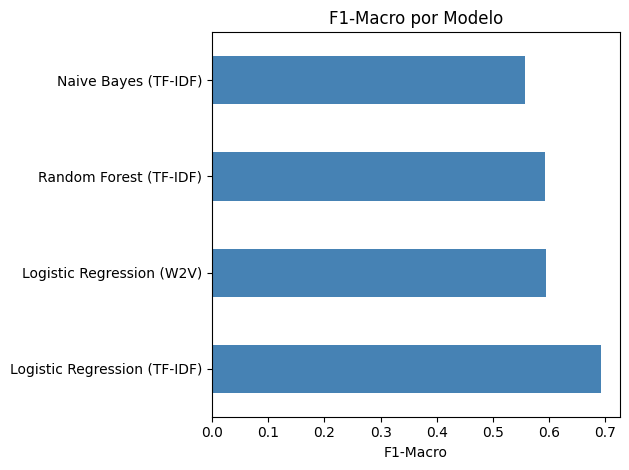

In [14]:
resultados = {
    'Logistic Regression (TF-IDF)': f1_score(y_test,  y_pred_lr,  average='macro'),
    'Naive Bayes (TF-IDF)':         f1_score(y_test,  y_pred_nb,  average='macro'),
    'Random Forest (TF-IDF)':       f1_score(y_test,  y_pred_rf,  average='macro'),
    'Logistic Regression (W2V)':    f1_score(y_te_w,  y_pred_w2v, average='macro'),
}

df_res = pd.DataFrame.from_dict(
    resultados, orient='index', columns=['F1-Macro']
).sort_values('F1-Macro', ascending=False)

print('=== Comparativo F1-Macro ===')
print(df_res.to_string())

df_res.plot(kind='barh', legend=False, color='steelblue')
plt.title('F1-Macro por Modelo')
plt.xlabel('F1-Macro')
plt.tight_layout()
plt.show()

## 8. (Opcional) BERTimbau

In [15]:
!pip install -q transformers[torch] datasets

In [16]:
import torch
from torch import nn
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

# BERTimbau recebe a letra original (Lyric), não o texto stemmatizado
# O próprio tokenizador BERT faz a segmentação internamente
df_bert = df_top5[['Lyric', 'genre_top5']].copy()
df_bert['labels'] = mlb.transform(df_bert['genre_top5']).tolist()
df_bert = df_bert.drop(columns=['genre_top5'])

train_df_b, val_df_b = train_test_split(df_bert, test_size=0.2, random_state=42)

train_ds = Dataset.from_pandas(train_df_b.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df_b.reset_index(drop=True))

model_name     = 'neuralmind/bert-base-portuguese-cased'
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(examples):
    result = tokenizer_bert(
        examples['Lyric'], padding='max_length', truncation=True, max_length=512
    )
    result['labels'] = [
        torch.tensor(lbl, dtype=torch.float32) for lbl in examples['labels']
    ]
    return result

tok_train = train_ds.map(tokenize_fn, batched=True, remove_columns=train_ds.column_names)
tok_val   = val_ds.map(tokenize_fn,   batched=True, remove_columns=val_ds.column_names)
tok_train.set_format('torch')
tok_val.set_format('torch')

print('Dataset tokenizado!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/27860 [00:00<?, ? examples/s]

Map:   0%|          | 0/6965 [00:00<?, ? examples/s]

Dataset tokenizado!


In [17]:
labels_arr      = np.array(train_df_b['labels'].tolist())
counts_b        = labels_arr.sum(axis=0)
pos_weights     = (len(train_df_b) - counts_b) / (counts_b + 1e-6)
pw_tensor       = torch.tensor(pos_weights, dtype=torch.float32).to('cuda')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss    = nn.BCEWithLogitsLoss(pos_weight=pw_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def custom_collator(features):
    return {
        'input_ids':      torch.stack([f['input_ids'] for f in features]),
        'attention_mask': torch.stack([f['attention_mask'] for f in features]),
        'labels':         torch.stack([f['labels'].to(torch.float32) for f in features]),
    }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs > 0.5).astype(float)
    return {
        'f1_micro': f1_score(labels, preds, average='micro'),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

model_bert = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(mlb.classes_),
    problem_type='multi_label_classification'
).to('cuda')

training_args = TrainingArguments(
    output_dir='./results_top5',
    eval_strategy='steps', eval_steps=100,
    save_strategy='steps', save_steps=100,
    fp16=True,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.1,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
)

trainer = WeightedTrainer(
    model=model_bert, args=training_args,
    train_dataset=tok_train, eval_dataset=tok_val,
    compute_metrics=compute_metrics, data_collator=custom_collator,
)
trainer.train()

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. C

Step,Training Loss,Validation Loss,F1 Micro,F1 Macro
100,0.775907,0.694234,0.604425,0.606423
200,0.606633,0.609243,0.664969,0.663722
300,0.554308,0.556062,0.705514,0.721300
400,0.558763,0.522754,0.714042,0.733824
500,0.534478,0.521601,0.712383,0.693706
600,0.516890,0.486879,0.737573,0.726199
700,0.488857,0.499179,0.739716,0.715896
800,0.472965,0.491298,0.737692,0.747697
900,0.460416,0.472834,0.731456,0.743754
1000,0.434935,0.490305,0.741184,0.738615


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2613, training_loss=0.4279482904814506, metrics={'train_runtime': 4090.5033, 'train_samples_per_second': 20.433, 'train_steps_per_second': 0.639, 'total_flos': 2.199141434714112e+16, 'train_loss': 0.4279482904814506, 'epoch': 3.0})

In [18]:
def predizer_top5(texto, threshold=0.5):
    inputs = tokenizer_bert(
        texto, return_tensors='pt', truncation=True, max_length=256, padding=True
    ).to(model_bert.device)
    with torch.no_grad():
        logits = model_bert(**inputs).logits
    probs   = torch.sigmoid(logits).cpu().numpy()[0]
    indices = np.where(probs > threshold)[0]
    return dict(zip(mlb.classes_[indices], probs[indices]))

# Exemplo:
# predizer_top5('Quando ergo meus olhos pro céu e minha voz se cala')

In [20]:
import os
import pickle

# Diretório de saída no Google Drive
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Projeto de NLP/bert_top5'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Salva o modelo e o tokenizador (formato HuggingFace)
model_bert.save_pretrained(SAVE_DIR)
tokenizer_bert.save_pretrained(SAVE_DIR)
print(f'✅ Modelo e tokenizador salvos em: {SAVE_DIR}')

# 2. Salva o MultiLabelBinarizer (necessário para decodificar predições)
mlb_path = os.path.join(SAVE_DIR, 'mlb_top5.pkl')
with open(mlb_path, 'wb') as f:
    pickle.dump(mlb, f)
print(f'✅ MultiLabelBinarizer salvo em: {mlb_path}')

# 3. Salva as classes para referência rápida
classes_path = os.path.join(SAVE_DIR, 'classes_top5.txt')
with open(classes_path, 'w') as f:
    f.write('\n'.join(mlb.classes_))
print(f'✅ Classes salvas em: {classes_path}')

# 4. Lista arquivos gerados
print('\n📁 Arquivos no diretório:')
for arq in sorted(os.listdir(SAVE_DIR)):
    print(f'  {arq}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modelo e tokenizador salvos em: /content/drive/MyDrive/Colab Notebooks/Projeto de NLP/bert_top5
✅ MultiLabelBinarizer salvo em: /content/drive/MyDrive/Colab Notebooks/Projeto de NLP/bert_top5/mlb_top5.pkl
✅ Classes salvas em: /content/drive/MyDrive/Colab Notebooks/Projeto de NLP/bert_top5/classes_top5.txt

📁 Arquivos no diretório:
  classes_top5.txt
  config.json
  mlb_top5.pkl
  model.safetensors
  tokenizer.json
  tokenizer_config.json


In [24]:
from sklearn.metrics import classification_report, f1_score
import numpy as np
import torch
from torch.utils.data import DataLoader

# ── 10a. Avaliação no conjunto de validação (tok_val) ──────────────────────
print('=== Avaliação no conjunto de validação ===')

model_bert.eval()
all_logits = []
all_labels = []

val_loader = DataLoader(
    tok_val, batch_size=32, shuffle=False, collate_fn=custom_collator
)

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(model_bert.device)
        attention_mask = batch['attention_mask'].to(model_bert.device)
        labels_batch   = batch['labels'].cpu().numpy()

        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        all_logits.append(outputs.logits.cpu().numpy())
        all_labels.append(labels_batch)

all_logits = np.vstack(all_logits)
all_labels = np.vstack(all_labels)

# Converte logits → probabilidades → predições binárias
probs_val = 1 / (1 + np.exp(-all_logits))
preds_val = (probs_val > 0.5).astype(int)

print(classification_report(all_labels, preds_val, target_names=mlb.classes_))
print(f'F1-Micro : {f1_score(all_labels, preds_val, average="micro"):.4f}')
print(f'F1-Macro : {f1_score(all_labels, preds_val, average="macro"):.4f}')

# ── 10b. Predição em textos livres ─────────────────────────────────────────
print('\n=== Predições em texto livre ===')

exemplos = [
    'Te dei o sol, te dei o mar Pra ganhar seu coração Você é raio de saudade Meteoro da paixão Explosão de sentimentos Que eu não pude acreditar Ah! Como é bom poder te amar!',
    'Pra que mentir, fingir que perdoou? Tentar ficar amigos sem rancor A emoção acabou Que coincidência é o amor A nossa música nunca mais tocou',
    'Não deixe o samba morrer Não deixe o samba acabar O morro foi feito de samba De samba para gente sambar',
]

for txt in exemplos:
    resultado = predizer_top5(txt, threshold=0.5)
    if resultado:
        generos = ', '.join(f'{g} ({p:.2%})' for g, p in resultado.items())
    else:
        generos = '(nenhum gênero acima do threshold)'
    print(f'\nTexto : {txt[:60]}...' if len(txt) > 60 else f'\nTexto : {txt}')
    print(f'Gêneros: {generos}')

# ── 10c. Distribuição de confiança por classe ──────────────────────────────
print('\n=== Confiança média por classe (validação) ===')
for i, cls in enumerate(mlb.classes_):
    media = probs_val[:, i].mean()
    print(f'  {cls:<20} prob média: {media:.4f}')

=== Avaliação no conjunto de validação ===
              precision    recall  f1-score   support

      gospel       0.91      0.96      0.93      1451
         mpb       0.82      0.83      0.83      3030
   sertanejo       0.66      0.84      0.74      1735
     hip hop       0.76      0.88      0.82       409
       samba       0.52      0.74      0.62      1531

   micro avg       0.73      0.84      0.78      8156
   macro avg       0.73      0.85      0.79      8156
weighted avg       0.74      0.84      0.79      8156
 samples avg       0.78      0.86      0.80      8156

F1-Micro : 0.7806
F1-Macro : 0.7866

=== Predições em texto livre ===

Texto : Te dei o sol, te dei o mar Pra ganhar seu coração Você é rai...
Gêneros: samba (86.35%)

Texto : Pra que mentir, fingir que perdoou? Tentar ficar amigos sem ...
Gêneros: mpb (88.08%), samba (90.47%)

Texto : Não deixe o samba morrer Não deixe o samba acabar O morro fo...
Gêneros: mpb (93.66%), hip hop (54.83%), samba (84.56%)

=== Co

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
